# Power efficiency of the LLC 

<img src= ".\figs\UNE.jpg">

## Table of contents

In [1]:
# LIBS 
import matplotlib.pyplot as plt 
import numpy as np 
# %pip install emi-receiver
from emi_receiver import receiver
import ast
from handcalcs import  render
from handcalcs import  *
import handcalcs
from localcode3 import *


# Initialization 
bl= '#1520c0' # blue 
rd= '#C62828' # red
fig_counter=1

### Introdution

Measuring the efficiency of a power electronic converter is challenging due to the sensitivity to measurement accuracy. For instance, a 1% overestimation on the primary-side measurement combined with a 1% underestimation on the secondary side results in a 2% reduction in calculated efficiency, decreasing it from 96% to 94%. <br>
The opposite is also true:minor measurement errors can similarly lead to an overestimation of efficiency.

For this test, shunt resistors will be employed to measure current using a millivoltmeter, while a voltmeter is used to measure voltage.

To minimize measurement errors, the same instruments are used for both primary and secondary voltage measurements (and similarly for current). This methodology requires waiting for the power transfer to stabilize before taking readings.

### Test setup

In [2]:
fig_counter=One_figure_with_captions(fig_counter, img1="setup.png"
                                     , caption1="Setup schematic",
                                     first_part_path="figs/" , 
                                     width=19)

In [3]:
fig_counter= show_figure_pair_with_captionsOLD(fig_counter, 
                                            img1="SHUNT1.jpg", 
                                            caption1="Shunt 50A 100mV", 
                                            img2="SHUNT2.jpg",#"IMG_20260209_161101.jpg", 
                                            caption2="Shunt 20A 50mV", 
                                            first_part_path="figs/" )

The detailed measurement methodology is provided in the introduction section.

### Efficiency

#### Measurements 

In [4]:
# aound 700kW/m3 (curve Relative core losses N97) 
# https://www.tdk-electronics.tdk.com/download/528886/81166f0de556e5b6a94db7793daed936/pdf-n97.pdf
Pv = 600e3  # W/m3 (600 at 200)
Volum =67745e-9 # Ve = 67745 mm3
Pv_w= Pv*Volum
print("# Pv_w= " , Pv_w, "w")
# Pv_w=  47.421499999999995 w

# Pv_w=  40.647 w


In [5]:
import pandas as pd
df= pd.read_csv("measurements.csv")#.astype("float32")

In [6]:
df

,Vin_v,V_shunt_inp_mV,Vout_v,V_shunt_out_mV
0,380.2,0.85,45.53,3.43
1,380.2,1.43,44.66,7.57
2,380.1,1.93,44.34,11.02
3,380.1,2.03,44.29,11.68
4,380.0,2.48,44.11,14.85
5,379.9,3.03,43.91,18.66
6,379.4,7.25,42.25,47.52


In [7]:
#df.columns

#### Efficiency calculations

In [8]:
R_shunt_prim  =50e-3/20 # v = ri  50mV 20A
R_shunt_second  =100e-3/50 # v = ri  100mV 50A
R_shunt_second, R_shunt_prim 

(0.002, 0.0025)

In [9]:
df["I_inp"]= 1e-3*df["V_shunt_inp_mV"]/R_shunt_prim
df["I_out"]= 1e-3*df["V_shunt_out_mV"]/R_shunt_second
df["Pin"]= df["I_inp"]*df["Vin_v"]
df["Pout"]= df["I_out"]*df["Vout_v"]
df["eff"]= 100*df["Pout"]/df["Pin"]
df["loss"]= df["Pin"]-df["Pout"]
df["R_load"]=df["Vout_v"]/df["I_out"]

In [10]:
df.round(2)

,Vin_v,V_shunt_inp_mV,Vout_v,V_shunt_out_mV,I_inp,I_out,Pin,Pout,eff,loss,R_load
0,380.2,0.85,45.53,3.43,0.34,1.72,129.27,78.08,60.40,51.18,26.55
1,380.2,1.43,44.66,7.57,0.57,3.78,217.47,169.04,77.73,48.44,11.80
2,380.1,1.93,44.34,11.02,0.77,5.51,293.44,244.31,83.26,49.12,8.05
3,380.1,2.03,44.29,11.68,0.81,5.84,308.64,258.65,83.80,49.99,7.58
4,380.0,2.48,44.11,14.85,0.99,7.42,376.96,327.52,86.88,49.44,5.94
5,379.9,3.03,43.91,18.66,1.21,9.33,460.44,409.68,88.98,50.76,4.71
6,379.4,7.25,42.25,47.52,2.90,23.76,1100.26,1003.86,91.24,96.40,1.78


In [11]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Efficiency and power loss of the DCDC - Vin = 380V')

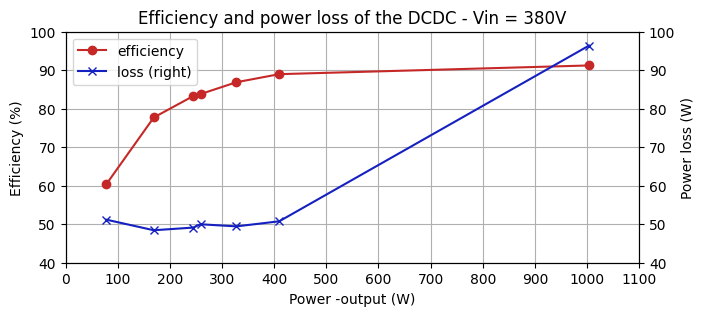

In [12]:
fig, ax = plt.subplots(figsize=(7.4, 3))

df.plot(x="Pout", y="eff", marker="o", ax=ax, c=rd, label = "efficiency")
df.plot(x="Pout", y="loss", marker="x", ax=ax, secondary_y=True, c=bl)

# Left axis (eff)
ax.set_ylim(40, 100)
ax.set_xlim(0, 1100)
ax.set_xticks(range(0, 1101, 100))

# Right axis (loss)
ax.right_ax.set_ylim(40, 100)

ax.grid()
ax.set_xlabel ("Power -output (W)")
ax.set_ylabel ("Efficiency (%)")
ax.right_ax.set_ylabel ("Power loss (W)")
ax.set_title("Efficiency and power loss of the DCDC - Vin = 380V")

### Areas for Improvement

#### Transformer loss

Transformer losses represent a major contributor to the reduction of the overall power-transfer efficiency of the DC-DC converter.

Below, a simplified estimation of the peak magnetic flux density in the transformer core is presented:

The magnetic core characteristics are specified in the ELP core datasheet [\[2\]](#referencesID4848878444887dd2).

In [13]:
%%render 
Vin = 380 # V
Freq = 100 # kHz 
N= 4 # turns
A_mm2=534.2# mm2 - see datasheet
A = A_mm2 * 1e-6 # m2

T = 1/(Freq*1e3)

# 
# L_uH = 80
# half bridge 
Li = (Vin/2)*T/2 # v=L.di/dt 

Flux = Li /N

deltaB = Flux /A
Bpeak = deltaB/2 # T
Bpeak_mT = Bpeak * 1e3 # mT
#print("# Bpeak ", 1e3*Bpeak,"mT")
# Bpeak  222.29502059153876 mT

<IPython.core.display.Latex object>

The TDK documentation [\[1\]](#referencesID4848878444887dd1) provides data on the relative core losses associated with the N97 magnetic material.

For a peak flux density of B_peak = 220 mT, the average volumetric core loss density (Pv), estimated between the 20°C and 100°C characteristic curves, is approximately 700 kW/m³.

In [14]:
fig_counter=One_figure_with_captions(fig_counter, img1="PV_N97.png"
                                     , caption1="Core loss of the transformer",
                                     first_part_path="figs/" , 
                                     width=7)

Based on the ELP core datasheet [\[2\]](#referencesID4848878444887dd2). the core loss can be estimated as follows.

In [15]:
%%render
Pv_kW=700 # kW/m3
P_nominal = 1200 # w
Pv = Pv_kW * 1000 # W/m3
Ve_mm3 = 67745 # mm3 - see datasheet
Ve = Ve_mm3 * 1e-9
P_loss= Pv * Ve # W
P_lossRelative = 100*P_loss/P_nominal # \%

<IPython.core.display.Latex object>

The estimated core loss is approximately 47.5 W. This value is reasonably accurate, as a consistent power loss of around 50 W is observed between 0 and 400 W, largely independent of the transmitted power(see the efficiency loss curve above). 

This core loss is relatively significant for a 1200 W DC-DC converter. Considering this loss alone, the corresponding efficiency reduction is already around **4%**.

#### Magnetizing Current

Due to the relatively low magnetizing inductance (83 µH), a significant peak current flows even under zero power transfer conditions. This results in increased Joule losses in both the copper and the primary-side MOSFETs.

Below a quick estimation of the peak magnetizing current: 

In [16]:
%%render 
Li # see formulas above
Lm_uH = 83 # µH
Lm= 1e-6 * Lm_uH 
I_peak = Li/Lm # A


<IPython.core.display.Latex object>

Assuming a total series resistance of approximately 100 mΩ for the PCB traces (primary side), MOSFETs, ..., and considering the primary current as a pure sinusoidal waveform, the estimated copper loss in the primary side is:

In [17]:
from math import *

In [18]:
%%render 
I_rms = I_peak/sqrt(2)
R_primaryLoop = 100e-3 # Ω
P_CopperPrimary= R_primaryLoop *I_rms**2 # W 
P_CopperPrimaryRelative=100  * P_CopperPrimary/P_nominal # \%

<IPython.core.display.Latex object>

An additional 0.6% efficiency loss occurs.

#### Output synchronous rectifier (SR)

As shown below, the turn-on time of the secondary MOSFET is dependent on the output current. Even at 250 W, the turn-on interval remains short, leading to extended conduction through the intrinsic body diode. This increased diode conduction significantly degrades the overall conversion efficiency.

In [19]:
fig_counter=One_figure_with_captions(fig_counter, img1="SR_Performance.png"
                                     , caption1="Secondary synchronous driver waveforms",
                                     first_part_path="figs/" , 
                                     width=19)

To understand this problem, I propose the simplified calculation below of the dead-time impact in a MOSFET power module.

In [20]:
%%render 
DeadTime= 0.05 # 1 \% of the perdiode
T_us = 10 
T = 1e-6 * T_us
Vf = 1
Vds_on = 0.3
I = 30
E_conductionDiode = 1e6*2*DeadTime*Vf *I *T 
E_conductionMos = 1e6*(1-2*DeadTime)*Vds_on *I *T
P_conductionTotal = 1e-6*(E_conductionDiode+E_conductionMos)/T # W

<IPython.core.display.Latex object>

The calculation is repeated below for a range of dead-time values:

In [21]:
arr= []
for DeadTime in (0,0.01,0.02,0.05,0.1,0.2):
    T_us = 10 
    T = 1e-6 * T_us
    Vf = 1.3
    Vds_on = 0.3
    I = 30
    E_conductionDiode = 1e6*2*DeadTime*Vf *I *T 
    E_conductionMos = 1e6*(1-2*DeadTime)*Vds_on *I *T
    P_conductionTotal = 1e-6*(E_conductionDiode+E_conductionMos)/T # W
    arr.append({
    "DeadTime %": DeadTime, 
    "E_conductionDiode µJ": E_conductionDiode, 
    "E_conductionMos µJ": E_conductionMos, 
    "P_conductionTotal W": P_conductionTotal})
pd.DataFrame(arr)

,DeadTime %,E_conductionDiode µJ,E_conductionMos µJ,P_conductionTotal W
0,0.00,0.0,90.0,9.0
1,0.01,7.8,88.2,9.6
2,0.02,15.6,86.4,10.2
3,0.05,39.0,81.0,12.0
4,0.10,78.0,72.0,15.0
5,0.20,156.0,54.0,21.0


Under simplified assumptions, it can be observed that a dead time of 2% increases the MOSFET conduction loss by approximately 50%, while a 20% dead time triples the loss.

### References

<a id="referencesID4848878444887dd1"></a> [1] [TDK, Ferrites and accessories, SIFERRIT material N97](https://www.tdk-electronics.tdk.com/download/528886/81166f0de556e5b6a94db7793daed936/pdf-n97.pdf)

<a id="referencesID4848878444887dd2"></a> [2] [TDK, ELP 102/20/38 with I 102/7/38 Datasheet](https://www.mouser.com/datasheet/2/400/elp_102_20_38-1527691.pdf)




